# Autoencoders — visualizing what they do

A short, mostly-visual walkthrough of an Autoencoder on Fashion-MNIST images.

**The idea:** an Autoencoder takes an image, squeezes it through a small bottleneck,
and tries to reconstruct it. To succeed, it must learn what's *essential* about each image.

```
   Image (784 pixels)  ──►  Encoder  ──►  Bottleneck (e.g. 32 numbers)  ──►  Decoder  ──►  Image (784 pixels)
                                              ↑
                                       compressed representation
```

Five visual moments tell the whole story:

1. What does the data look like?
2. Train an Autoencoder. Compare original vs. reconstruction.
3. Vary the bottleneck size. What gets lost when we compress harder?
4. Force a 2D bottleneck. Visualize the latent space.
5. Walk a line between two images in latent space — see them morph.

Don't worry about the code details — the goal is the *pictures*. Run all cells top to bottom.

---

## Setup

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [5]:
# Fashion-MNIST: 60,000 grayscale 28x28 images of clothing items.
# (Same shape as MNIST digits, but visually richer — better for showing reconstruction trade-offs.)

transform = transforms.ToTensor()  # converts PIL image → tensor with values in [0, 1]

train_set = datasets.FashionMNIST("./data", train=True, download=True, transform=transform)
test_set  = datasets.FashionMNIST("./data", train=False, download=True, transform=transform)

class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print(f"Training images: {len(train_set):,}   ·   Test images: {len(test_set):,}")
print(f"Each image: 28x28 grayscale = 784 pixels")

100.0%
100.0%
100.0%
100.0%


Training images: 60,000   ·   Test images: 10,000
Each image: 28x28 grayscale = 784 pixels


---

## 1. What does the data look like?

Before doing anything else: look at samples. We'll work with these.

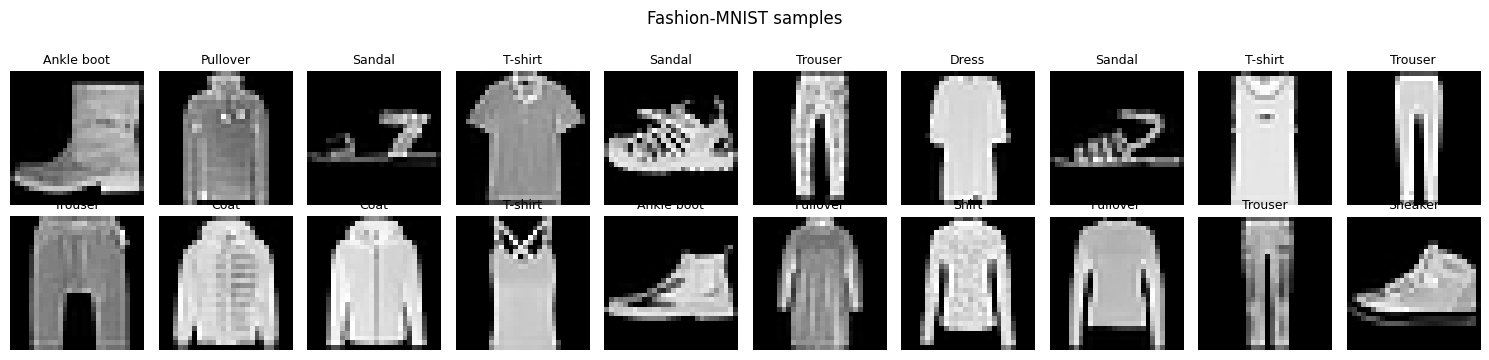

In [6]:
# Show a grid of 20 random training images
fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
indices = torch.randperm(len(train_set))[:20]
for ax, idx in zip(axes.flatten(), indices):
    img, label = train_set[int(idx)]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(class_names[label], fontsize=9)
    ax.axis("off")
plt.suptitle("Fashion-MNIST samples", y=1.02)
plt.tight_layout()
plt.show()

---

## 2. Build a simple Autoencoder

Two small networks, glued together: the **encoder** squeezes 784 pixels down to a small
vector. The **decoder** expands it back to 784 pixels. Both are just stacked linear layers.

The Autoencoder's loss is **MSE between input and reconstruction** — the model learns to
make the reconstruction as close to the original as possible, despite the bottleneck.

In [7]:
class Autoencoder(nn.Module):
    def __init__(self, bottleneck_dim=32):
        super().__init__()
        # Encoder: 784 → 256 → 64 → bottleneck
        self.encoder = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64),  nn.ReLU(),
            nn.Linear(64, bottleneck_dim),
        )
        # Decoder: bottleneck → 64 → 256 → 784
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 64), nn.ReLU(),
            nn.Linear(64, 256),            nn.ReLU(),
            nn.Linear(256, 784),           nn.Sigmoid(),  # outputs in [0, 1] like pixels
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z


# Helper to train an autoencoder for a few epochs
def train_autoencoder(bottleneck_dim, epochs=5, batch_size=256):
    model = Autoencoder(bottleneck_dim=bottleneck_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        epoch_loss = 0.0
        for images, _ in loader:
            images = images.view(-1, 784).to(device)
            recon, _ = model(images)
            loss = loss_fn(recon, images)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * images.size(0)
        epoch_loss /= len(train_set)
        print(f"  bottleneck={bottleneck_dim:>3d}  epoch {epoch+1}/{epochs}  loss={epoch_loss:.4f}")
    return model

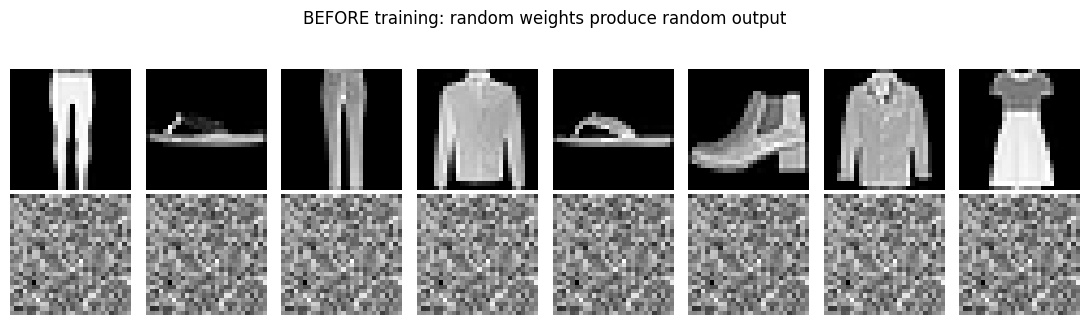

In [16]:
# What does the autoencoder do BEFORE training? Nothing useful — its weights are random.
# Let's see.

untrained = Autoencoder(bottleneck_dim=32).to(device)
untrained.eval()

# Pick the same kind of test images we'll use after training
indices = torch.randperm(len(test_set))[:8]
originals, recons_untrained = [], []
with torch.no_grad():
    for idx in indices:
        img, _ = test_set[int(idx)]
        x = img.view(1, 784).to(device)
        recon, _ = untrained(x)
        originals.append(img.squeeze().numpy())
        recons_untrained.append(recon.cpu().view(28, 28).numpy())

# Plot
fig, axes = plt.subplots(2, 8, figsize=(11, 3.2))
for i in range(8):
    axes[0, i].imshow(originals[i], cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(recons_untrained[i], cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("original",         rotation=0, ha="right", va="center", fontsize=11)
axes[1, 0].set_ylabel("untrained output", rotation=0, ha="right", va="center", fontsize=11)
plt.suptitle("BEFORE training: random weights produce random output", y=1.02)
plt.tight_layout()
plt.show()

---

## 3. Original vs. reconstruction

Let's train an Autoencoder with a **bottleneck of 32 numbers** (compressing 784 → 32 = 24× squeeze)
and look at what comes out.

In [8]:
print("Training Autoencoder with bottleneck=32...")
model_32 = train_autoencoder(bottleneck_dim=32, epochs=5)

Training Autoencoder with bottleneck=32...
  bottleneck= 32  epoch 1/5  loss=0.0509
  bottleneck= 32  epoch 2/5  loss=0.0240
  bottleneck= 32  epoch 3/5  loss=0.0208
  bottleneck= 32  epoch 4/5  loss=0.0190
  bottleneck= 32  epoch 5/5  loss=0.0180


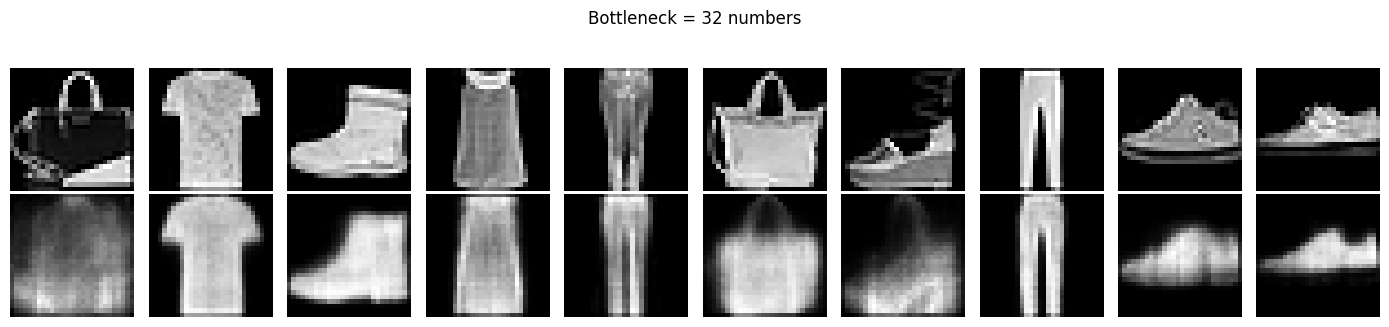

In [10]:
def show_reconstructions(model, n=10, title=""):
    """Show n test images and their reconstructions side by side."""
    model.eval()
    indices = torch.randperm(len(test_set))[:n]
    originals, recons = [], []
    with torch.no_grad():
        for idx in indices:
            img, _ = test_set[int(idx)]
            x = img.view(1, 784).to(device)
            recon, _ = model(x)
            originals.append(img.squeeze().numpy())
            recons.append(recon.cpu().view(28, 28).numpy())
    
    fig, axes = plt.subplots(2, n, figsize=(n * 1.4, 3.2))
    for i in range(n):
        axes[0, i].imshow(originals[i], cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(recons[i], cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("original",     rotation=0, ha="right", va="center", fontsize=11)
    axes[1, 0].set_ylabel("reconstructed", rotation=0, ha="right", va="center", fontsize=11)
    if title:
        plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

show_reconstructions(model_32, n=10, title="Bottleneck = 32 numbers")

**What you should see:** the reconstructions look quite close to the originals.
A bit blurry, but you can clearly tell sneakers from coats from trousers.

The Autoencoder has learned to compress each 784-pixel image into 32 numbers and back —
without ever being told what a sneaker or a coat *is*. It found whatever 32 numbers it
needed to reconstruct *any* Fashion-MNIST image.

This is **representation learning** — and the model did it without any labels.
That makes it a **self-supervised** task: the "label" is the image itself.

---

## 4. What happens when we compress harder?

The bottleneck size is a hyperparameter. We chose 32. What if we try 64? Or 8? Or 2?

The bigger the bottleneck, the more information survives — but also the less the model has
to "summarize". The smaller the bottleneck, the more the reconstruction has to *guess*.

In [11]:
# Train autoencoders at different bottleneck sizes
models_by_size = {}
for size in [64, 16, 4, 2]:
    print(f"\nTraining bottleneck={size}...")
    models_by_size[size] = train_autoencoder(bottleneck_dim=size, epochs=5)


Training bottleneck=64...
  bottleneck= 64  epoch 1/5  loss=0.0498
  bottleneck= 64  epoch 2/5  loss=0.0241
  bottleneck= 64  epoch 3/5  loss=0.0206
  bottleneck= 64  epoch 4/5  loss=0.0187
  bottleneck= 64  epoch 5/5  loss=0.0177

Training bottleneck=16...
  bottleneck= 16  epoch 1/5  loss=0.0486
  bottleneck= 16  epoch 2/5  loss=0.0235
  bottleneck= 16  epoch 3/5  loss=0.0205
  bottleneck= 16  epoch 4/5  loss=0.0188
  bottleneck= 16  epoch 5/5  loss=0.0179

Training bottleneck=4...
  bottleneck=  4  epoch 1/5  loss=0.0503
  bottleneck=  4  epoch 2/5  loss=0.0263
  bottleneck=  4  epoch 3/5  loss=0.0237
  bottleneck=  4  epoch 4/5  loss=0.0226
  bottleneck=  4  epoch 5/5  loss=0.0218

Training bottleneck=2...
  bottleneck=  2  epoch 1/5  loss=0.0522
  bottleneck=  2  epoch 2/5  loss=0.0324
  bottleneck=  2  epoch 3/5  loss=0.0306
  bottleneck=  2  epoch 4/5  loss=0.0297
  bottleneck=  2  epoch 5/5  loss=0.0289


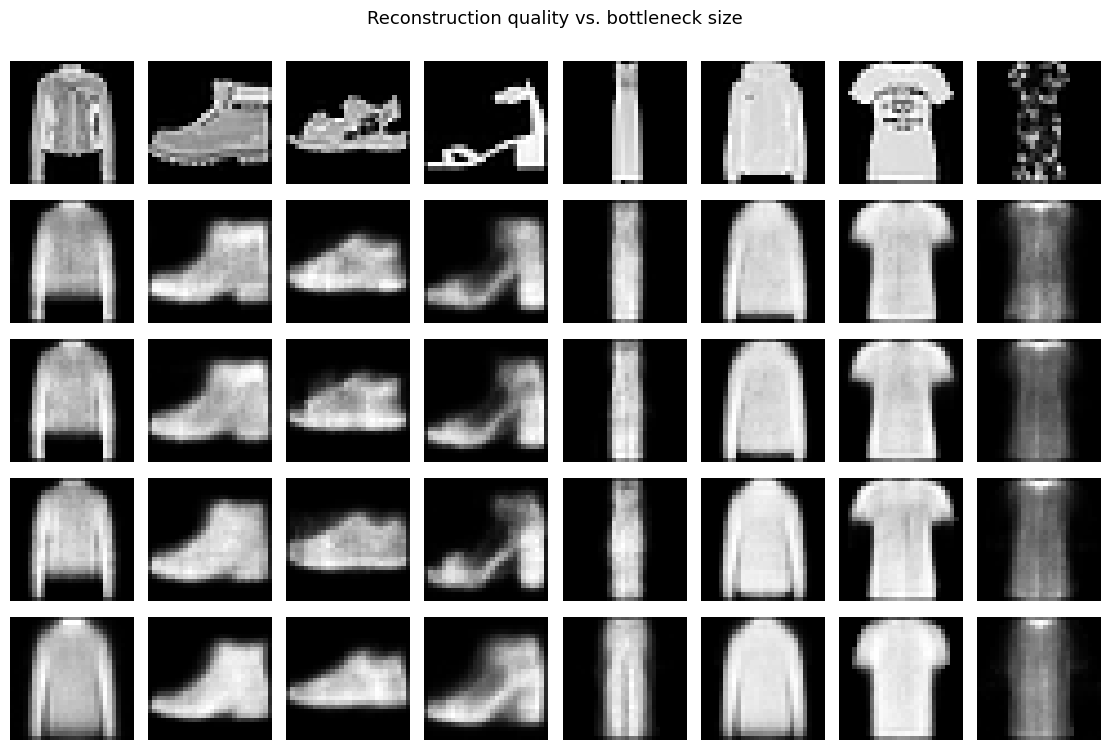

In [12]:
# Show reconstructions side by side for all bottleneck sizes
N_SAMPLES = 8
fixed_indices = torch.randperm(len(test_set))[:N_SAMPLES]
fixed_images = [test_set[int(i)][0] for i in fixed_indices]

fig, axes = plt.subplots(len(models_by_size) + 1, N_SAMPLES,
                         figsize=(N_SAMPLES * 1.4, (len(models_by_size) + 1) * 1.5))

# Top row: originals
for i, img in enumerate(fixed_images):
    axes[0, i].imshow(img.squeeze().numpy(), cmap="gray")
    axes[0, i].axis("off")
axes[0, 0].set_ylabel("ORIGINAL", rotation=0, ha="right", va="center", fontsize=10, weight="bold")

# Each next row: reconstructions at a given bottleneck size
for row_idx, (size, model) in enumerate(models_by_size.items(), start=1):
    model.eval()
    with torch.no_grad():
        for col_idx, img in enumerate(fixed_images):
            x = img.view(1, 784).to(device)
            recon, _ = model(x)
            axes[row_idx, col_idx].imshow(recon.cpu().view(28, 28).numpy(), cmap="gray")
            axes[row_idx, col_idx].axis("off")
    axes[row_idx, 0].set_ylabel(f"size {size}", rotation=0, ha="right", va="center", fontsize=10)

plt.suptitle("Reconstruction quality vs. bottleneck size", fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

**Read the rows from top to bottom:**

- **Original** — what we started with.
- **Bottleneck 64** — almost lossless. The model has plenty of room.
- **Bottleneck 16** — slightly blurrier, but every item is still recognizable.
- **Bottleneck 4** — major compression. Items lose detail; some categories get confused.
- **Bottleneck 2** — only **two numbers** to describe each image. Reconstructions become
  generic prototypes — sometimes the model averages between classes.

The trade-off is clear: smaller bottleneck = more compression = more information loss.
But what survives is the *most essential* information — the part that all variations
of an image share.

100.0%
100.0%
100.0%
100.0%


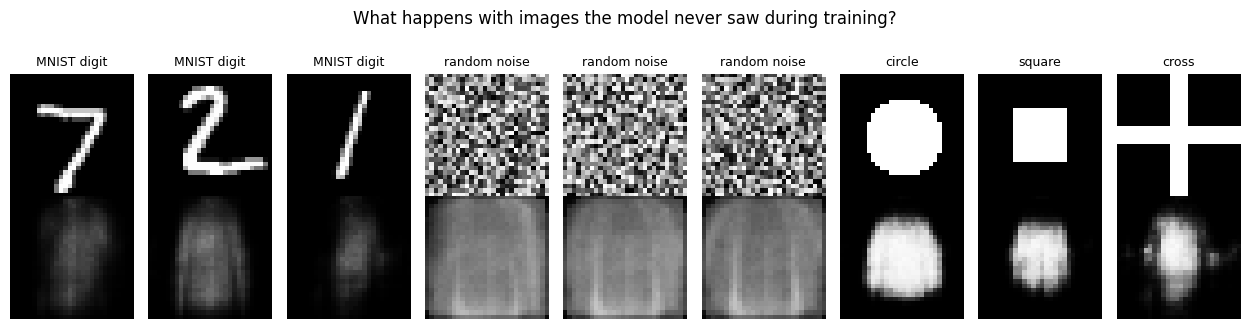

In [15]:
# === Out-of-distribution test: what if we feed images the model has NEVER seen? ===

# Three kinds of "weird" inputs the model wasn't trained on:
weird_images = []
weird_labels = []

# (1) MNIST digits — different shapes, same format. Try to load them.
try:
    mnist = datasets.MNIST("./data", train=False, download=True, transform=transform)
    for i in range(3):
        img, _ = mnist[i]
        weird_images.append(img.squeeze().numpy())
        weird_labels.append(f"MNIST digit")
except Exception:
    print("MNIST not available, skipping.")

# (2) Pure random noise
for _ in range(3):
    noise = np.random.rand(28, 28).astype(np.float32)
    weird_images.append(noise)
    weird_labels.append("random noise")

# (3) Geometric shapes — drawn with numpy
def make_circle():
    img = np.zeros((28, 28), dtype=np.float32)
    yy, xx = np.ogrid[:28, :28]
    mask = (xx - 14)**2 + (yy - 14)**2 < 80
    img[mask] = 1.0
    return img

def make_square():
    img = np.zeros((28, 28), dtype=np.float32)
    img[8:20, 8:20] = 1.0
    return img

def make_cross():
    img = np.zeros((28, 28), dtype=np.float32)
    img[12:16, :] = 1.0
    img[:, 12:16] = 1.0
    return img

for shape_fn, name in [(make_circle, "circle"), (make_square, "square"), (make_cross, "cross")]:
    weird_images.append(shape_fn())
    weird_labels.append(name)

# Run them through the trained Fashion-MNIST autoencoder
model_32.eval()
recons = []
with torch.no_grad():
    for img in weird_images:
        x = torch.from_numpy(img).view(1, 784).to(device)
        recon, _ = model_32(x)
        recons.append(recon.cpu().view(28, 28).numpy())

# Plot original vs reconstruction for every weird image
n = len(weird_images)
fig, axes = plt.subplots(2, n, figsize=(n * 1.4, 3.2))
for i in range(n):
    axes[0, i].imshow(weird_images[i], cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(weird_labels[i], fontsize=9)
    axes[0, i].axis("off")
    axes[1, i].imshow(recons[i], cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("input",          rotation=0, ha="right", va="center", fontsize=11)
axes[1, 0].set_ylabel("reconstructed",  rotation=0, ha="right", va="center", fontsize=11)
plt.suptitle("What happens with images the model never saw during training?", y=1.02)
plt.tight_layout()
plt.show()

---

## 5. The 2D latent space

When we set the bottleneck to **just 2 numbers**, every image gets mapped to a single point
in a 2D plane. We can plot all of them — and color by class label.

If the model learned something meaningful, similar items should cluster together.

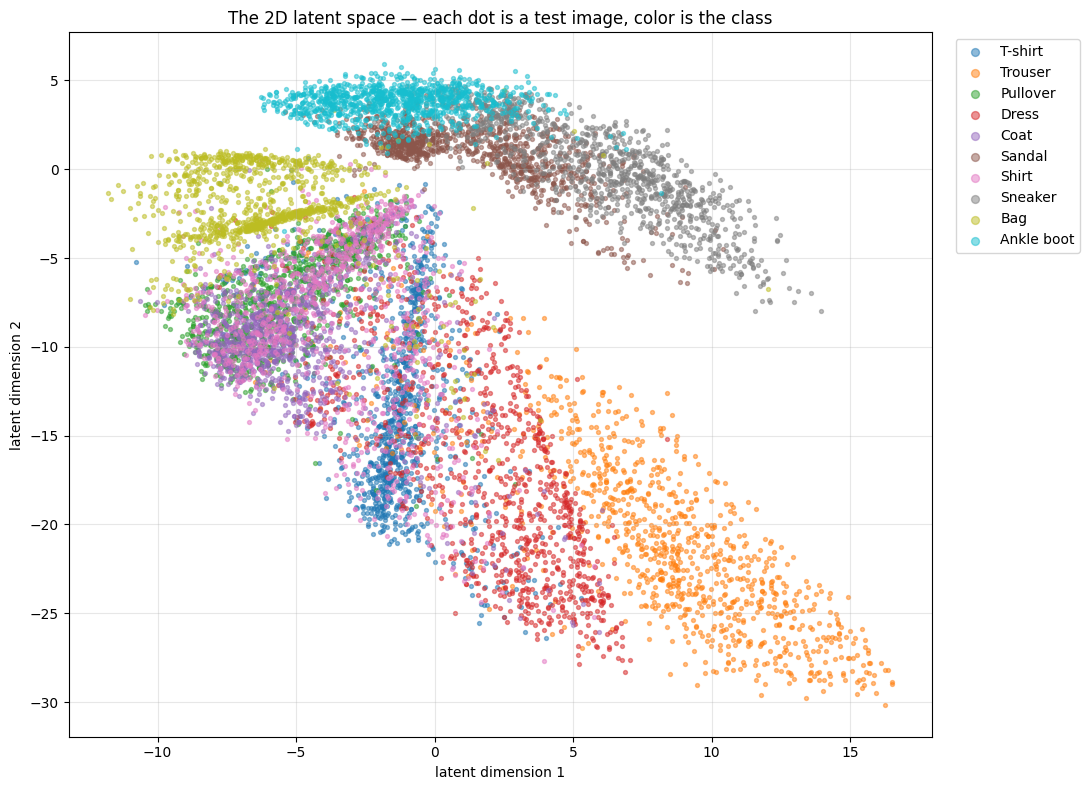

In [13]:
# Use the bottleneck-2 model from above
model_2d = models_by_size[2]
model_2d.eval()

# Encode every test image into 2D
all_z, all_labels = [], []
loader = DataLoader(test_set, batch_size=512, shuffle=False)
with torch.no_grad():
    for images, labels in loader:
        images = images.view(-1, 784).to(device)
        _, z = model_2d(images)
        all_z.append(z.cpu().numpy())
        all_labels.append(labels.numpy())
all_z = np.concatenate(all_z)
all_labels = np.concatenate(all_labels)

# Plot the latent space
fig, ax = plt.subplots(figsize=(11, 8))
cmap = plt.get_cmap("tab10")
for class_idx in range(10):
    mask = all_labels == class_idx
    ax.scatter(all_z[mask, 0], all_z[mask, 1],
               s=8, alpha=0.5, color=cmap(class_idx),
               label=class_names[class_idx])
ax.set_xlabel("latent dimension 1")
ax.set_ylabel("latent dimension 2")
ax.set_title("The 2D latent space — each dot is a test image, color is the class")
ax.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**What you see:** the model — which never knew what a "sneaker" or "coat" *is* — has
naturally placed similar items near each other in the latent space. Trousers form one cluster,
footwear another, tops yet another.

This is the magic of representation learning. The model wasn't given labels. It just had to
reconstruct images through a tight bottleneck — and that pressure forced it to organize images
by their underlying structure.

> This is exactly the reason **Phase 1 (representation)** is such a powerful idea — and why
> autoencoder-like methods are at the heart of modern self-supervised learning, including LLMs.

---

## 6. Walking between two images

If the latent space is meaningful, we should be able to *interpolate*: pick two images,
encode both, walk along a straight line between their latent codes, and decode each step.

The result should be a smooth morph from one image to the other.

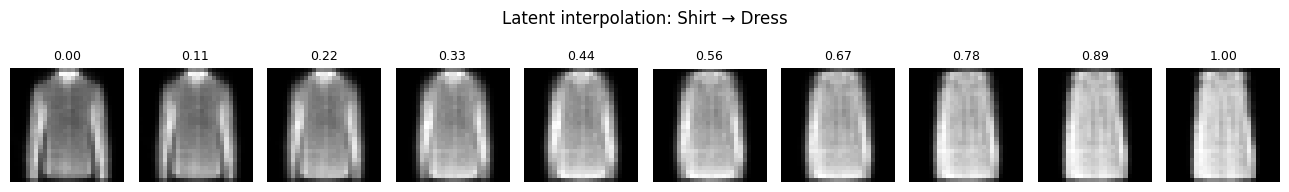

In [14]:
# Use the bottleneck-32 model — bigger latent space gives smoother morphs
model = model_32
model.eval()

# Pick two images from different classes for an interesting morph
img_a, lbl_a = test_set[7]      # something
img_b, lbl_b = test_set[42]     # something else

with torch.no_grad():
    z_a = model.encoder(img_a.view(1, 784).to(device))
    z_b = model.encoder(img_b.view(1, 784).to(device))

# Interpolate: 10 steps from z_a to z_b
steps = 10
alphas = np.linspace(0, 1, steps)
fig, axes = plt.subplots(1, steps, figsize=(steps * 1.3, 1.8))

with torch.no_grad():
    for i, alpha in enumerate(alphas):
        z = (1 - alpha) * z_a + alpha * z_b
        img = model.decoder(z).cpu().view(28, 28).numpy()
        axes[i].imshow(img, cmap="gray")
        axes[i].axis("off")
        axes[i].set_title(f"{alpha:.2f}", fontsize=9)

plt.suptitle(f"Latent interpolation: {class_names[lbl_a]} → {class_names[lbl_b]}",
             fontsize=12, y=1.05)
plt.tight_layout()
plt.show()

**What you see:** a smooth transition from one image to the other — passing through
intermediate, plausible-looking shapes. The model can generate images at any point along
the line, not just the ones it was trained on.

This is also why autoencoders are sometimes called *generative* models: once trained,
you can sample new latent codes and decode them into new images.

---

## Wrap-up

Five things this notebook showed:

1. **Autoencoders compress and reconstruct.** Their goal is to recreate the input through
   a bottleneck — no labels needed.

2. **Reconstruction quality drops as the bottleneck shrinks.** Bigger bottleneck = more
   information preserved.

3. **The model learns *representations* in the bottleneck.** Even with just 2 numbers per
   image, similar items end up near each other.

4. **Self-supervised learning** is happening here: the "label" is the image itself.
   The same idea drives modern LLMs — predict-the-next-token is exactly this trick,
   applied to text.

5. **Latent spaces are smooth.** Interpolating between two encoded images produces sensible
   intermediate images — a hint of why autoencoder-style methods underlie image generation
   models.

> **The 4 takeaways for ML literacy:**
> - Models can learn structure without labels.
> - That structure is captured in a *latent representation*.
> - Compression forces the model to find what's essential.
> - This is the foundation of modern self-supervised learning.